<a href="https://colab.research.google.com/github/amaansadat/SRDT/blob/main/DecisionTree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df=pd.read_csv("titanic_dataset.csv")

In [ ]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.isnull().value_counts()

PassengerId  Survived  Pclass  Name   Sex    Age    SibSp  Parch  Ticket  Fare   Cabin  Embarked
False        False     False   False  False  False  False  False  False   False  True   False       529
                                                                                 False  False       183
                                             True   False  False  False   False  True   False       158
                                                                                 False  False        19
                                             False  False  False  False   False  False  True          2
Name: count, dtype: int64

In [ ]:
len(df)

891

In [ ]:
df.drop(['Cabin','Name','Ticket'],axis=1,inplace=True)

In [ ]:
df['Age'].fillna(df['Age'].median(),inplace=True)

/tmp/ipykernel_4105/1527141296.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(),inplace=True)


In [ ]:
df['Embarked'].fillna(df['Embarked'].mode()[0],inplace=True)

/tmp/ipykernel_4105/3717664479.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0],inplace=True)


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [ ]:
df=pd.get_dummies(df,columns=['Sex','Embarked'],drop_first=True)
df.head()

KeyError: "None of [Index(['Sex', 'Embarked'], dtype='object')] are in the [columns]"

In [ ]:
X=df.drop('Survived',axis=1)
y=df['Survived']

In [ ]:
X


,PassengerId,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,1,3,22.0,1,0,7.2500,True,False,True
1,2,1,38.0,1,0,71.2833,False,False,False
2,3,3,26.0,0,0,7.9250,False,False,True
3,4,1,35.0,1,0,53.1000,False,False,True
4,5,3,35.0,0,0,8.0500,True,False,True
...,...,...,...,...,...,...,...,...,...
886,887,2,27.0,0,0,13.0000,True,False,True
887,888,1,19.0,0,0,30.0000,False,False,True
888,889,3,28.0,1,2,23.4500,False,False,True
889,890,1,26.0,0,0,30.0000,True,False,False


In [ ]:
y

,Survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1



--- Fold 1 ---
Accuracy: 0.7207
Confusion Matrix:
[[81 24]
 [26 48]]
Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.77      0.76       105
           1       0.67      0.65      0.66        74

    accuracy                           0.72       179
   macro avg       0.71      0.71      0.71       179
weighted avg       0.72      0.72      0.72       179



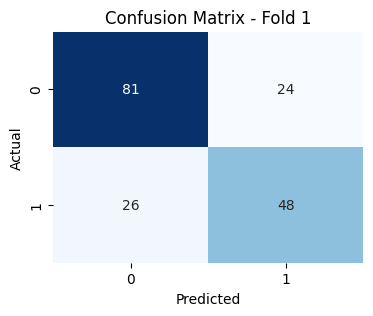


--- Fold 2 ---
Accuracy: 0.7416
Confusion Matrix:
[[98 13]
 [33 34]]
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.88      0.81       111
           1       0.72      0.51      0.60        67

    accuracy                           0.74       178
   macro avg       0.74      0.70      0.70       178
weighted avg       0.74      0.74      0.73       178



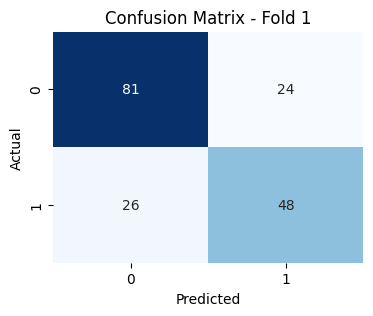

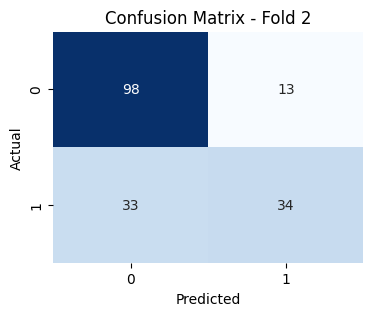


--- Fold 3 ---
Accuracy: 0.7921
Confusion Matrix:
[[90 18]
 [19 51]]
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.83      0.83       108
           1       0.74      0.73      0.73        70

    accuracy                           0.79       178
   macro avg       0.78      0.78      0.78       178
weighted avg       0.79      0.79      0.79       178



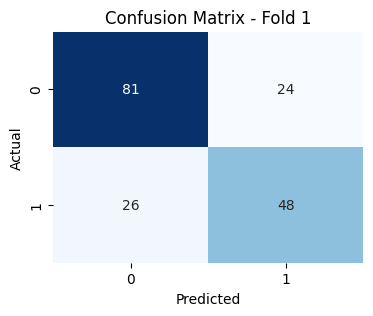

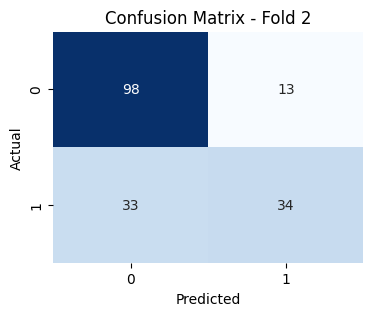

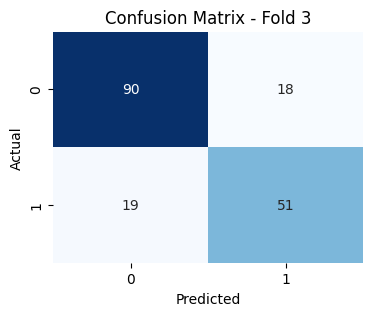


--- Fold 4 ---
Accuracy: 0.7640
Confusion Matrix:
[[92 20]
 [22 44]]
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.82      0.81       112
           1       0.69      0.67      0.68        66

    accuracy                           0.76       178
   macro avg       0.75      0.74      0.75       178
weighted avg       0.76      0.76      0.76       178



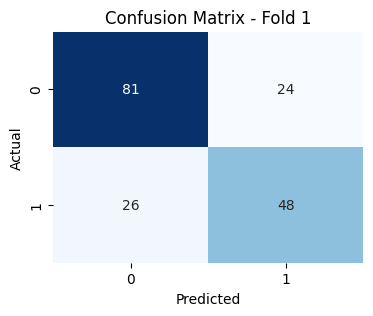

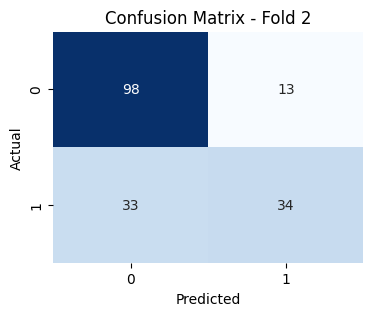

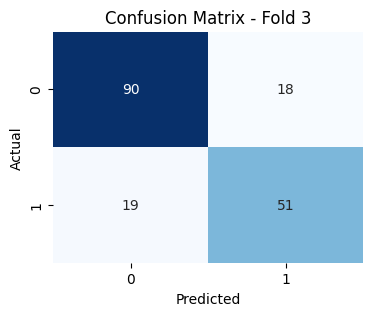

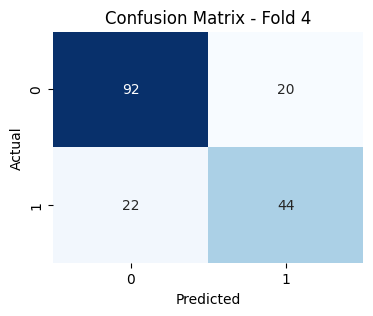


--- Fold 5 ---
Accuracy: 0.7584
Confusion Matrix:
[[86 27]
 [16 49]]
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.76      0.80       113
           1       0.64      0.75      0.70        65

    accuracy                           0.76       178
   macro avg       0.74      0.76      0.75       178
weighted avg       0.77      0.76      0.76       178



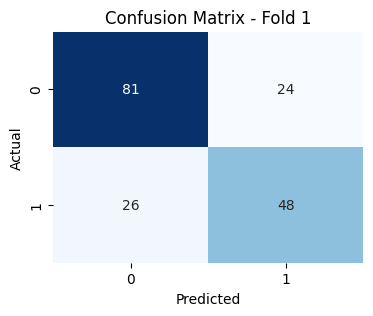

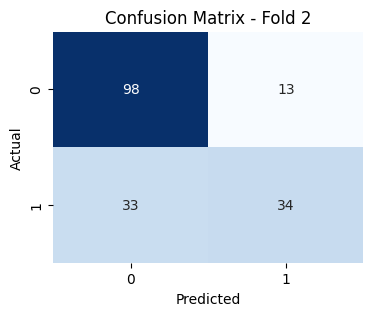

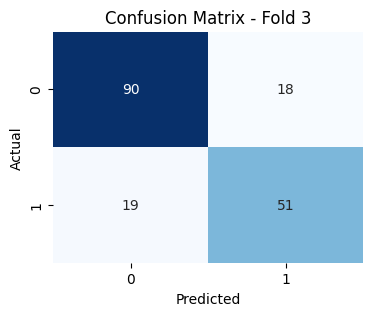

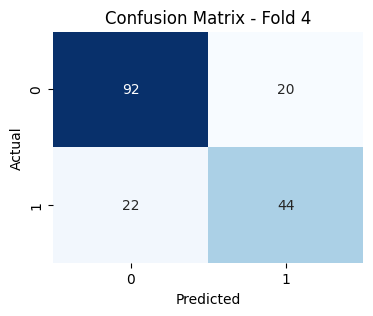

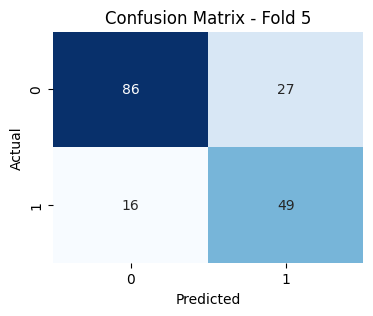


=== Overall Performance ===
Accuracies per Fold: ['0.7207', '0.7416', '0.7921', '0.7640', '0.7584']
Average Accuracy: 0.7554


In [ ]:
from sklearn.model_selection import KFold
#from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Initialize KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Initialize model
#model = SVC(kernel='rbf', gamma=0.0001, C=100.0)
model = DecisionTreeClassifier(criterion='entropy', random_state=42)

fold = 1
accuracies = []
conf_matrices = []
class_reports = []

for train_index, test_index in kf.split(X):
    print(f"\n--- Fold {fold} ---")

    # Split data manually
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Train model
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    conf_matrices.append(cm)

    # Classification Report
    cr = classification_report(y_test, y_pred, output_dict=False)
    class_reports.append(cr)

    # Print Results
    print(f"Accuracy: {acc:.4f}")
    print("Confusion Matrix:")
    print(cm)
    print("Classification Report:")
    print(cr)

    '''
    # Plot accuracy per fold
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(accuracies)+1), accuracies, marker='o', linestyle='-', color='blue')
    plt.axhline(np.mean(accuracies), color='red', linestyle='--', label=f'Avg Accuracy: {np.mean(accuracies):.2f}')
    plt.title('Accuracy per Fold')
    plt.xlabel('Fold Number')
    plt.ylabel('Accuracy')
    plt.xticks(range(1, len(accuracies)+1))
    plt.ylim(0.5, 1.0)
    plt.legend()
    plt.grid(True)
    plt.show()
    '''
    # Plot confusion matrices for each fold
    for i, cm in enumerate(conf_matrices):
        plt.figure(figsize=(4, 3))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
        plt.title(f'Confusion Matrix - Fold {i+1}')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.show()

    fold += 1

# Summary
print("\n=== Overall Performance ===")
print("Accuracies per Fold:", [f"{a:.4f}" for a in accuracies])
print(f"Average Accuracy: {np.mean(accuracies):.4f}")